# DAG Learning

In [ ]:
# import matplotlib as mpl
# mpl.rcParams.update({
#     "font.family": "Times",
#     "font.size": 12,
#     "axes.titlesize": 12,
#     "axes.labelsize": 12,
#     "xtick.labelsize": 12,
#     "ytick.labelsize": 12,
#     "legend.fontsize": 11,
#     # make math text (e.g., Greek, subscripts) use Times New Roman too
#     "mathtext.fontset": "custom",
#     "mathtext.rm": "Times",
#     "mathtext.it": "Times",
#     "mathtext.bf": "Times",
#     # optional: ensure minus signs render correctly
#     "axes.unicode_minus": False,
# })

/tmp/ipykernel_35851/3040869716.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  get_cmap('tab20c')


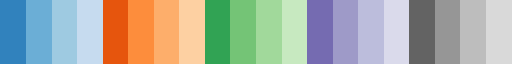

In [34]:
get_cmap('tab20c')

/tmp/ipykernel_38562/4237456918.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('tab20c')


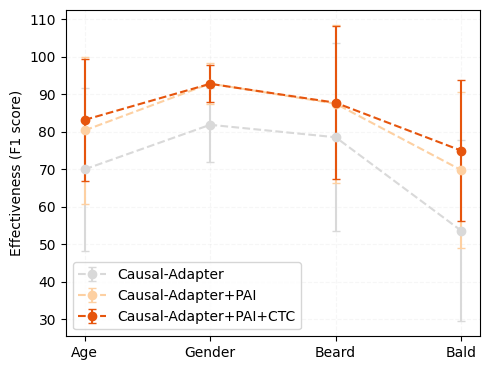

In [23]:
# Re-plot as a line plot with error bars and grid in the background, using viridis colormap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import get_cmap


# Data as provided
data = {
    "Method": ["Causal-Adapter", "Causal-Adapter+PAI", "Causal-Adapter+PAI+CTC"],
    "Age mean":   [69.975, 80.35, 83.15],
    "age std":    [21.64738244, 19.69678485, 16.16714776],
    "Gender":     [81.85, 92.825, 92.775],
    "Gender std":[9.881126791, 5.407633493, 4.893107397],
    "Beard mean":[78.525, 87.475, 87.725],
    "beard std": [25.11551645, 21.01735394, 20.45651893],
    "Bald mean": [53.625, 69.775, 74.975],
    "bald std":  [24.19729668, 20.89298128, 18.84055909],
}

df = pd.DataFrame(data)

attributes = ["Age", "Gender", "Beard", "Bald"]
means_cols = ["Age mean", "Gender", "Beard mean", "Bald mean"]
std_cols   = ["age std", "Gender std", "beard std", "bald std"]
methods = df["Method"].tolist()

x = np.arange(len(attributes))

# Viridis colors
# cmap = get_cmap('viridis')
# colors = [cmap(v) for v in np.linspace(0.2, 1.0, len(methods))]
cmap = get_cmap('tab20c')
colors= [cmap(19),cmap(7),cmap(4)]

plt.figure(figsize=(5, 3.8))
for i, (method, color) in enumerate(zip(methods, colors)):
    means = df.loc[i, means_cols].values.astype(float)
    stds  = df.loc[i, std_cols].values.astype(float)
    plt.errorbar(x, means, yerr=stds, label=method, color=color,
                 marker='o', linestyle='--', capsize=3,alpha=1)

plt.xticks(x, attributes)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
plt.ylabel("Effectiveness (F1 score)")
# plt.title("Effectiveness by Attribute (mean ± std) — Line Plot (viridis)")
plt.grid(True, linestyle="--", alpha=0.1)
plt.legend(loc="lower left")
plt.tight_layout()


plt.show()


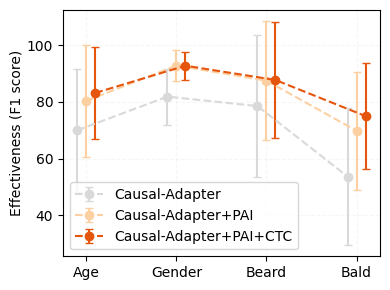

In [24]:
plt.figure(figsize=(4, 3))

offset = 0.1  # small horizontal shift
for i, (method, color) in enumerate(zip(methods, colors)):
    means = df.loc[i, means_cols].values.astype(float)
    stds  = df.loc[i, std_cols].values.astype(float)
    # Apply a horizontal shift for each method
    plt.errorbar(x + (i - (len(methods)-1)/2)*offset, means, yerr=stds,
                 label=method, color=color, marker='o',
                 linestyle='--', capsize=3, alpha=1)

plt.xticks(x, attributes)
plt.ylabel("Effectiveness (F1 score)", labelpad=2) 
plt.grid(True, linestyle="--", alpha=0.1)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

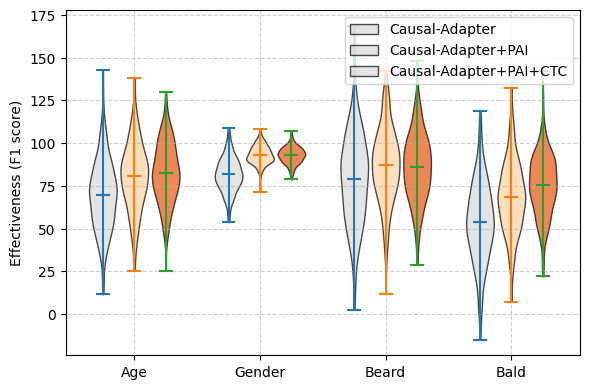

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import get_cmap

# Data
data = {
    "Method": ["Causal-Adapter", "Causal-Adapter+PAI", "Causal-Adapter+PAI+CTC"],
    "Age mean":   [69.975, 80.35, 83.15],
    "age std":    [21.64738244, 19.69678485, 16.16714776],
    "Gender":     [81.85, 92.825, 92.775],
    "Gender std":[9.881126791, 5.407633493, 4.893107397],
    "Beard mean":[78.525, 87.475, 87.725],
    "beard std": [25.11551645, 21.01735394, 20.45651893],
    "Bald mean": [53.625, 69.775, 74.975],
    "bald std":  [24.19729668, 20.89298128, 18.84055909],
}
df = pd.DataFrame(data)

attributes = ["Age", "Gender", "Beard", "Bald"]
means_cols = ["Age mean", "Gender", "Beard mean", "Bald mean"]
std_cols   = ["age std", "Gender std", "beard std", "bald std"]
methods = df["Method"].tolist()

# Colormap
# cmap = get_cmap('viridis')
# colors = [cmap(v) for v in np.linspace(0.2, 1.0, len(methods))]

plt.figure(figsize=(6, 4))

# Simulate distributions for violin plot
n_samples = 500  # number of samples to simulate per mean/std
positions = np.arange(len(attributes))

for i, (method, color) in enumerate(zip(methods, colors)):
    simulated_data = []
    pos = []
    for j, (m, s) in enumerate(zip(means_cols, std_cols)):
        samples = np.random.normal(df.loc[i, m], df.loc[i, s], n_samples)
        simulated_data.append(samples)
        pos.append(positions[j] + i*0.25)  # small shift to separate methods

    parts = plt.violinplot(simulated_data, positions=pos, widths=0.22, showmeans=True)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)

plt.xticks(positions + 0.25, attributes)
plt.ylabel("Effectiveness (F1 score)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(methods)
plt.tight_layout()
plt.show()


/tmp/ipykernel_37213/4128389828.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('viridis')


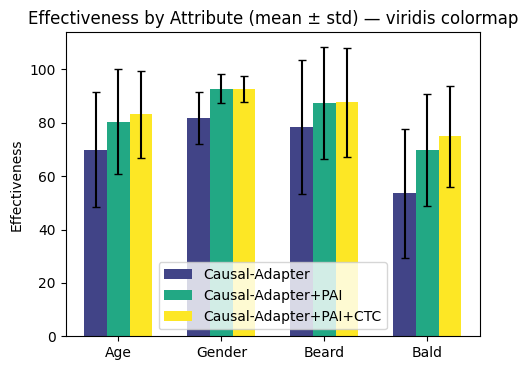

In [4]:
# Build the table from the user's data and plot a single figure with error bars.
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.cm import get_cmap



# Prepare plotting
attributes = ["Age", "Gender", "Beard", "Bald"]
means_cols = ["Age mean", "Gender", "Beard mean", "Bald mean"]
std_cols   = ["age std", "Gender std", "beard std", "bald std"]

methods = df["Method"].tolist()
n_attr = len(attributes)
n_methods = len(methods)

import numpy as np
x = np.arange(n_attr)  # attribute positions
width = 0.22  # bar width per method

cmap = get_cmap('viridis')
colors = [cmap(v) for v in np.linspace(0.2, 1.0, len(methods))]

plt.figure(figsize=(5, 3.8))
for i, (method, color) in enumerate(zip(methods, colors)):
    means = df.loc[i, means_cols].values.astype(float)
    stds  = df.loc[i, std_cols].values.astype(float)
    plt.bar(x + (i - (len(methods)-1)/2)*width, means, width,
            yerr=stds, capsize=3, label=method, color=color, edgecolor='none')

plt.xticks(x, attributes)
plt.ylabel("Effectiveness")
plt.title("Effectiveness by Attribute (mean ± std) — viridis colormap")
plt.legend()
plt.tight_layout()
plt.show()

# FID, CLD

/tmp/ipykernel_38562/3410517244.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('tab20c')


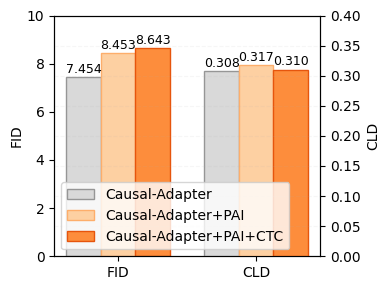

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.cm import get_cmap

# Data
data = {
    "Method": ["Causal-Adapter", "Causal-Adapter+PAI", "Causal-Adapter+PAI+CTC"],
    "FID":   [7.454, 8.453, 8.643],
    "CLD":   [0.308, 0.317, 0.310],
}
df = pd.DataFrame(data)

methods = df["Method"].tolist()
metrics = ["FID", "CLD"]
x = np.arange(len(metrics))   # 0 for FID, 1 for CLD
width = 0.25                  # bar width

# Colors from viridis
#cmap = get_cmap("viridis")
#colors = [cmap(v) for v in np.linspace(0.2, 1.0, len(methods))]
cmap = get_cmap('tab20c')
colors= [cmap(19),cmap(7),cmap(5)]
edgecolors = [cmap(17),cmap(6),cmap(4)]
fig, ax1 = plt.subplots(figsize=(4, 3))

# FID on left y-axis
for i, (method, color,edcolor) in enumerate(zip(methods, colors,edgecolors)):
    fid_val = df.loc[i, "FID"]
    bar = ax1.bar(x[0] + (i - (len(methods)-1)/2)*width, fid_val,
                  width, label=method if metrics[0] else "", color=color,edgecolor=edcolor)
    ax1.text(bar[0].get_x() + bar[0].get_width()/2, fid_val + 0.05,
             f"{fid_val:.3f}", ha="center", va="bottom", fontsize=9)

ax1.set_ylabel("FID", labelpad=2)
ax1.tick_params(axis="y", )
ax1.set_ylim(0,10)

# CLD on right y-axis
ax2 = ax1.twinx()

for i, (method, color,edcolor) in enumerate(zip(methods, colors,edgecolors)):
    cld_val = df.loc[i, "CLD"]
    bar = ax2.bar(x[1] + (i - (len(methods)-1)/2)*width, cld_val,
                  width, color=color, edgecolor=edcolor)
    ax2.text(bar[0].get_x() + bar[0].get_width()/2, cld_val + 0.002,
             f"{cld_val:.3f}", ha="center", va="bottom", fontsize=9)

ax2.set_ylabel("CLD")
ax2.tick_params(axis="y")
ax2.set_ylim(0,0.4)
# Shared x-axis
plt.xticks(x, metrics)
#ax1.grid(True, axis="y", linestyle="--", alpha=1.0)
ax2.grid(True, axis="y", linestyle="--", alpha=0.1)
handles, labels = ax1.get_legend_handles_labels()
ax2.legend(handles, labels, loc="lower left", frameon=True)
# Legend for methods
#ax2.legend(loc="lower left")
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


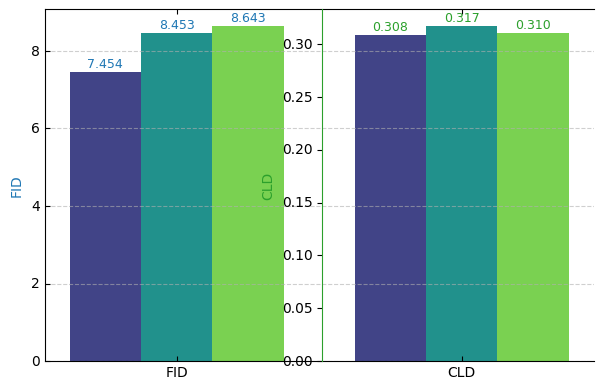

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# axisartist imports
import mpl_toolkits.axisartist as AA
from mpl_toolkits.axes_grid1 import host_subplot

# ------------------ Data ------------------
data = {
    "Method": ["Causal-Adapter", "Causal-Adapter+PAI", "Causal-Adapter+PAI+CTC"],
    "FID":   [7.454, 8.453, 8.643],
    "CLD":   [0.308, 0.317, 0.310],
}
df = pd.DataFrame(data)

methods = df["Method"].tolist()
metrics = ["FID", "CLD"]
x = np.arange(len(metrics))          # positions: 0 for FID group, 1 for CLD group
width = 0.25

# Colors
colors = [plt.cm.viridis(v) for v in np.linspace(0.2, 0.8, len(methods))]

# ------------------ AxisArtist host/parasite ------------------
fig = plt.figure(figsize=(6.0, 4.0))
host = host_subplot(111, axes_class=AA.Axes)   # axisartist host (FID axis)
fig.add_subplot(host)

par = host.twinx()                              # parasite axis (CLD axis)

# Hide host right & parasite right axes (we'll put both on left)
host.axis["right"].set_visible(False)
par.axis["right"].set_visible(False)

# Put both y-axes on the LEFT
host.axis["left"].set_axis_direction("left")    # FID on left (outer)
par.axis["left"].set_axis_direction("left")     # CLD on left too

# Move the CLD (parasite) left axis **inside** the plot (offset in points)
# Positive x-offset moves it to the right from the left spine.
par.axis["left"] = par.new_fixed_axis(loc="left", offset=(200, 0))  # tweak 40→closer/farther

# Label colors (optional for clarity)
host.axis["left"].label.set_text("FID")
par.axis["left"].label.set_text("CLD")
host.axis["left"].label.set_color("tab:blue")
par.axis["left"].label.set_color("tab:green")
par.axis["left"].line.set_color("tab:green")
par.axis["left"].major_ticks.set_tick_out(True)

# ------------------ Bars ------------------
# FID bars on host
for i, (method, color) in enumerate(zip(methods, colors)):
    val = df.loc[i, "FID"]
    b = host.bar(x[0] + (i - (len(methods)-1)/2)*width, val, width,
                 color=color, label=method if i == 0 else "")
    host.text(b[0].get_x() + b[0].get_width()/2, val + 0.05,
              f"{val:.3f}", ha="center", va="bottom", fontsize=9, color="tab:blue")

# CLD bars on parasite
for i, (method, color) in enumerate(zip(methods, colors)):
    val = df.loc[i, "CLD"]
    b = par.bar(x[1] + (i - (len(methods)-1)/2)*width, val, width,
                color=color, edgecolor="none")
    par.text(b[0].get_x() + b[0].get_width()/2, val + 0.002,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, color="tab:green")

# ------------------ X-axis, grid, legend ------------------
host.set_xticks(x)
host.set_xticklabels(metrics)
host.grid(True, axis="y", linestyle="--", alpha=0.6)

# Methods legend centered above
ax1.legend(methods, loc="lower left")

plt.tight_layout()
plt.show()


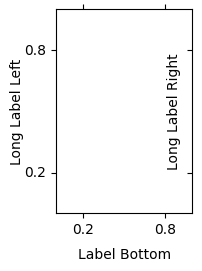

In [71]:
import matplotlib.pyplot as plt

import mpl_toolkits.axisartist.axislines as axislines


def setup_axes(fig, pos):
    ax = fig.add_subplot(pos, axes_class=axislines.Axes)
    ax.set_yticks([0.2, 0.8])
    ax.set_xticks([0.2, 0.8])
    return ax


fig = plt.figure(figsize=(6, 3))
fig.subplots_adjust(bottom=0.2)

ax = setup_axes(fig, 133)
ax.axis["left"].set_axis_direction("left")
ax.axis["right"].set_axis_direction("left")
ax.axis[:].major_ticks.set_tick_out(True)

ax.axis["left"].label.set_text("Long Label Left")
ax.axis["bottom"].label.set_text("Label Bottom")
ax.axis["right"].label.set_text("Long Label Right")
ax.axis["right"].label.set_visible(True)
ax.axis["left"].label.set_pad(0)
ax.axis["bottom"].label.set_pad(10)

plt.show()

# Appendix

/tmp/ipykernel_38562/349661125.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('tab20c')


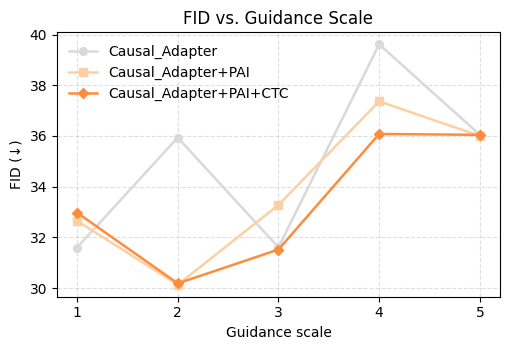

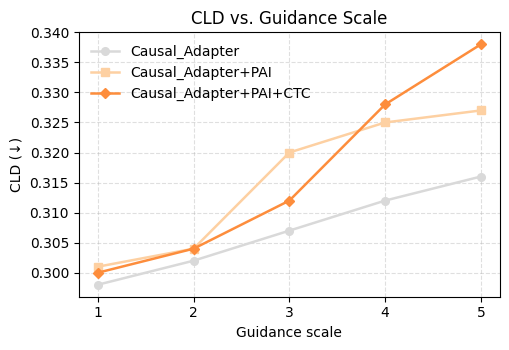

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.cm import get_cmap

# ---- Tidy the data (from your table) ---------------------------------
rows = [
    # Causal_Adapter
    ("Causal_Adapter",              1, 31.597, 0.298),
    ("Causal_Adapter",              2, 35.936, 0.302),
    ("Causal_Adapter",              3, 31.604, 0.307),
    ("Causal_Adapter",              4, 39.614, 0.312),
    ("Causal_Adapter",              5, 36.044, 0.316),
    # Causal_Adapter+PAI
    ("Causal_Adapter+PAI",          1, 32.653, 0.301),
    ("Causal_Adapter+PAI",          2, 30.132, 0.304),
    ("Causal_Adapter+PAI",          3, 33.278, 0.320),
    ("Causal_Adapter+PAI",          4, 37.366, 0.325),
    ("Causal_Adapter+PAI",          5, 36.000, 0.327),
    # Causal_Adapter+PAI+CTC  (your third block; had mixed labels—normalized here)
    ("Causal_Adapter+PAI+CTC",      1, 32.975, 0.300),
    ("Causal_Adapter+PAI+CTC",      2, 30.182, 0.304),
    ("Causal_Adapter+PAI+CTC",      3, 31.520, 0.312),
    ("Causal_Adapter+PAI+CTC",      4, 36.079, 0.328),
    ("Causal_Adapter+PAI+CTC",      5, 36.044, 0.338),
]

df = pd.DataFrame(rows, columns=["Method", "Guidance", "FID", "CLD"])
df["Guidance"] = df["Guidance"].astype(int)

methods = df["Method"].unique().tolist()
guidances = sorted(df["Guidance"].unique())

# Colors & markers
cmap = get_cmap('tab20c')
colors= {"Causal_Adapter":cmap(19),"Causal_Adapter+PAI":cmap(7),"Causal_Adapter+PAI+CTC":cmap(5)}
# cmap = get_cmap("viridis")
# colors = {m: cmap(i) for m, i in zip(methods, np.linspace(0.2, 0.85, len(methods)))}
markers = ["o", "s", "D", "^", "v"]

def plot_metric(metric: str, ylabel: str, title: str = None, ylim=None, savepath=None):
    fig, ax = plt.subplots(figsize=(5.2, 3.6))
    for idx, m in enumerate(methods):
        sub = df[df["Method"] == m].sort_values("Guidance")
        ax.plot(
            sub["Guidance"], sub[metric],
            marker=markers[idx % len(markers)],
            linestyle="-", linewidth=1.8, markersize=5.5,
            color=colors[m], label=m
        )
    ax.set_xticks(guidances)
    ax.set_xlabel("Guidance scale")
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if title:
        ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="best", frameon=False)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

# ---- Plot 1: FID vs guidance scale (lower is better) ------------------
plot_metric("FID", ylabel="FID (↓)", title="FID vs. Guidance Scale")

# ---- Plot 2: CLD vs guidance scale (lower is better) ------------------
plot_metric("CLD", ylabel="CLD (↓)", title="CLD vs. Guidance Scale")


In [3]:
guidances

[50, 100, 200, 500]

/tmp/ipykernel_47017/73248218.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('tab20c')


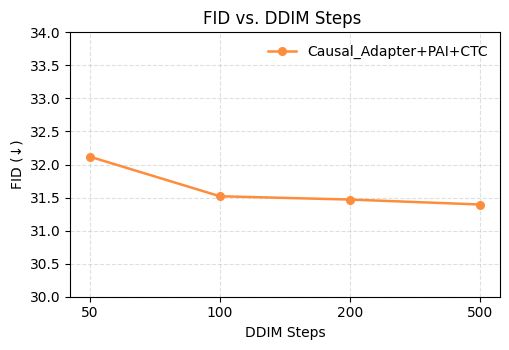

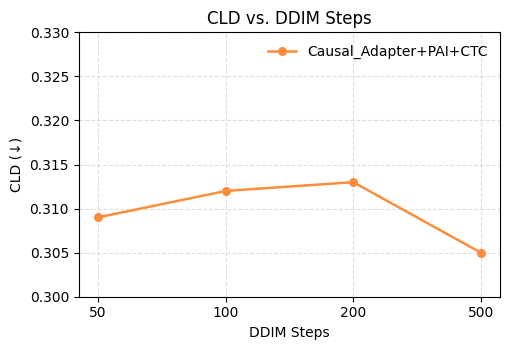

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.cm import get_cmap

# ---- Tidy the data (from your table) ---------------------------------
rows = [

    # Causal_Adapter+PAI+CTC  (your third block; had mixed labels—normalized here)
    ("Causal_Adapter+PAI+CTC",      50, 32.12, 0.309),
    ("Causal_Adapter+PAI+CTC",      100, 31.52, 0.312),
    ("Causal_Adapter+PAI+CTC",      200, 31.47, 0.313),
    ("Causal_Adapter+PAI+CTC",      500, 31.395, 0.305),

]

df = pd.DataFrame(rows, columns=["Method", "Guidance", "FID", "CLD"])
df["Guidance"] = df["Guidance"].astype(int)

methods = df["Method"].unique().tolist()
guidances = sorted(df["Guidance"].unique())

# Colors & markers
cmap = get_cmap('tab20c')
colors= {"Causal_Adapter":cmap(19),"Causal_Adapter+PAI":cmap(7),"Causal_Adapter+PAI+CTC":cmap(5)}
# cmap = get_cmap("viridis")
# colors = {m: cmap(i) for m, i in zip(methods, np.linspace(0.2, 0.85, len(methods)))}
markers = ["o", "s", "D", "^", "v"]


def plot_metric(metric: str, ylabel: str, title: str = None, ylim=None, savepath=None):
    fig, ax = plt.subplots(figsize=(5.2, 3.6))
    for idx, m in enumerate(methods):
        sub = df[df["Method"] == m].sort_values("Guidance")
        ax.plot(
            range(len(sub["Guidance"])), sub[metric],
            marker=markers[idx % len(markers)],
            linestyle="-", linewidth=1.8, markersize=5.5,
            color=colors[m], label=m
        )
    ax.set_xticks(range(len(guidances)))
    ax.set_xticklabels([str(g) for g in guidances])
    #ax.set_xticks(guidances)
    ax.set_xlabel("DDIM Steps")
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if title:
        ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.4)
    
    ax.legend(loc="best", frameon=False)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

# ---- Plot 1: FID vs guidance scale (lower is better) ------------------
plot_metric("FID", ylabel="FID (↓)", title="FID vs. DDIM Steps ",ylim=(30,34))

# ---- Plot 2: CLD vs guidance scale (lower is better) ------------------
plot_metric("CLD", ylabel="CLD (↓)", title="CLD vs. DDIM Steps",ylim=(0.3,0.33))


/tmp/ipykernel_40568/388676814.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('tab20c')


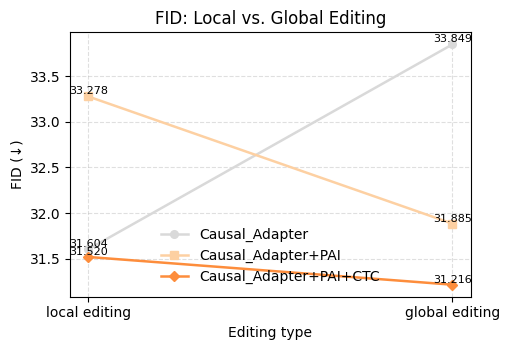

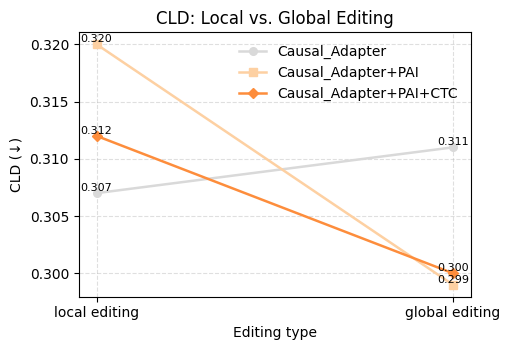

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.cm import get_cmap

# ---------- Data ----------
rows = [
    ("Causal_Adapter",             "local editing",  31.604, 0.307),
    ("Causal_Adapter",             "global editing", 33.849, 0.311),
    ("Causal_Adapter+PAI",         "local editing",  33.278, 0.320),
    ("Causal_Adapter+PAI",         "global editing", 31.885, 0.299),
    ("Causal_Adapter+PAI+CTC",     "local editing",  31.520, 0.312),
    ("Causal_Adapter+PAI+CTC",     "global editing", 31.216, 0.300),
]

df = pd.DataFrame(rows, columns=["Method", "EditType", "FID", "CLD"])

methods   = df["Method"].unique().tolist()
edits     = ["local editing", "global editing"]  # keep order
x_pos     = np.arange(len(edits))               # [0, 1]

# Colors & markers
cmap = get_cmap('tab20c')
colors = {
    "Causal_Adapter":             cmap(19),
    "Causal_Adapter+PAI":         cmap(7),
    "Causal_Adapter+PAI+CTC":     cmap(5),
}
markers = ["o", "s", "D"]

def plot_metric(metric: str, ylabel: str, title: str = None, ylim=None, savepath=None):
    fig, ax = plt.subplots(figsize=(5.2, 3.6))

    for idx, m in enumerate(methods):
        sub = df[df["Method"] == m].set_index("EditType").loc[edits]  # ensure order
        ax.plot(
            x_pos, sub[metric].values,
            marker=markers[idx % len(markers)],
            linestyle="-", linewidth=1.8, markersize=5.5,
            color=colors[m], label=m
        )

        # optional: annotate values
        for xp, val in zip(x_pos, sub[metric].values):
            ax.text(xp, val, f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(edits)
    ax.set_xlabel("Editing type")
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if title:
        ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="best", frameon=False)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

# ---- Plot 1: FID (lower is better) ----
plot_metric("FID", ylabel="FID (↓)", title="FID: Local vs. Global Editing")

# ---- Plot 2: CLD (lower is better) ----
plot_metric("CLD", ylabel="CLD (↓)", title="CLD: Local vs. Global Editing")
